# Gaussian Naive Bayes=

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
np.set_printoptions(precision=4, suppress=True)

In [4]:
df = pd.read_csv('data/VLagun_Phys_Years3.csv')
display(df.head())
print('Ksztalt danych:', df.shape)
print('Rozklad klas Years:')
print(df['Years'].value_counts().sort_index())

,PSU,O2,temp.,SS,DOC,TPOC,Windspeedinsitu,Depth,Years
0,3.757624,9.46,18.3,52.0,7.500,8.5650,3.5,3.3,0
1,3.504707,9.89,19.1,50.0,7.860,8.5200,0.0,3.6,0
2,3.757624,9.66,18.1,59.0,8.172,8.4915,1.0,3.4,0
3,3.107266,10.36,19.5,46.0,7.848,8.8320,0.0,2.9,0
4,2.619498,11.56,19.0,42.0,7.536,9.2400,0.0,3.0,0


Ksztalt danych: (120, 9)
Rozklad klas Years:
Years
0    64
1    56
Name: count, dtype: int64


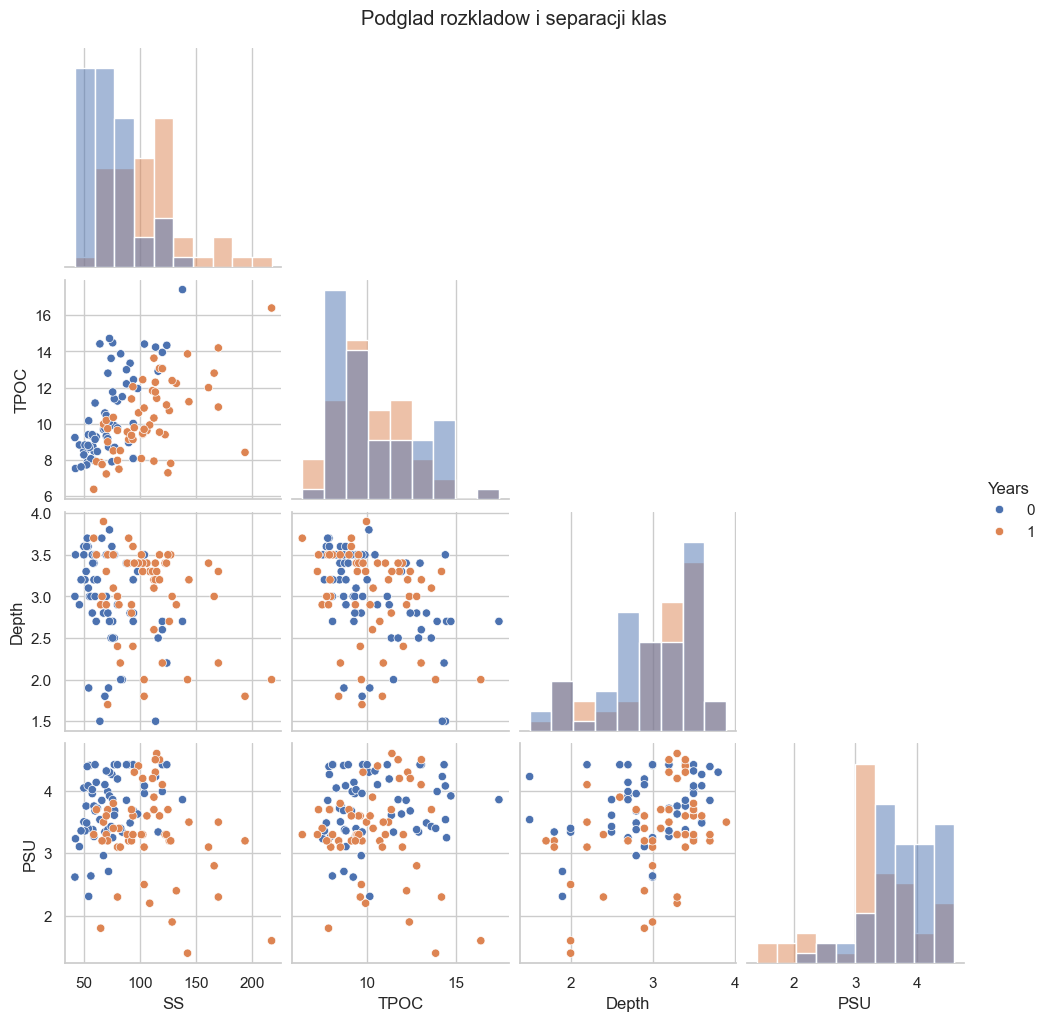

In [5]:
pairplots_cols = ['SS', 'TPOC', 'Depth', 'PSU', 'Years']
sns.pairplot(df[pairplots_cols], hue='Years', diag_kind='hist', corner=True)
plt.suptitle('Podglad rozkladow i separacji klas', y=1.02)
plt.show()

In [6]:
def run_gnb_for_pair(dataframe, feature_pair, target_col='Years', test_size=0.3, random_state=42):
    X = dataframe[list(feature_pair)].copy()
    y = dataframe[target_col].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    model = GaussianNB()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f'=== Para cech: {feature_pair[0]} i {feature_pair[1]} ===')
    print(f'Accuracy: {acc:.4f}')
    print('\nConfusion matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('\nClassification report:')
    print(classification_report(y_test, y_pred, digits=4))

    proba_df = pd.DataFrame(y_proba, columns=[f'P(Years={c})' for c in model.classes_])
    proba_df['y_true'] = y_test.to_numpy()
    proba_df['y_pred'] = y_pred

    print('\nPrzykladowe prawdopodobienstwa a posteriori (predict_proba):')
    display(proba_df.head(10))

    # Wizualizacja granicy decyzyjnej dla dwoch cech
    x_min, x_max = X[feature_pair[0]].min() - 1, X[feature_pair[0]].max() + 1
    y_min, y_max = X[feature_pair[1]].min() - 1, X[feature_pair[1]].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 5))
    plt.contourf(xx, yy, zz, alpha=0.20, cmap='coolwarm')
    sns.scatterplot(
        data=dataframe,
        x=feature_pair[0],
        y=feature_pair[1],
        hue=target_col,
        palette='coolwarm',
        alpha=0.85,
        edgecolor='black'
    )
    plt.title(f'GaussianNB: {feature_pair[0]} vs {feature_pair[1]}')
    plt.show()

    return {
        'features': feature_pair,
        'accuracy': acc,
        'model': model,
        'proba_table': proba_df
    }

## Test hipotezy

=== Para cech: SS i TPOC ===
Accuracy: 0.7778

Confusion matrix:
[[17  2]
 [ 6 11]]

Classification report:
              precision    recall  f1-score   support

           0     0.7391    0.8947    0.8095        19
           1     0.8462    0.6471    0.7333        17

    accuracy                         0.7778        36
   macro avg     0.7926    0.7709    0.7714        36
weighted avg     0.7897    0.7778    0.7735        36


Przykladowe prawdopodobienstwa a posteriori (predict_proba):


,P(Years=0),P(Years=1),y_true,y_pred
0,0.802967,0.197033,0,0
1,0.801222,0.198778,0,0
2,0.787720,0.212280,0,0
3,0.825206,0.174794,0,0
4,0.789084,0.210916,0,0
5,0.000924,0.999076,1,1
6,0.002467,0.997533,1,1
7,0.750515,0.249485,0,0
8,0.401528,0.598472,1,1
9,0.506317,0.493683,0,0


C:\Users\mix13\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


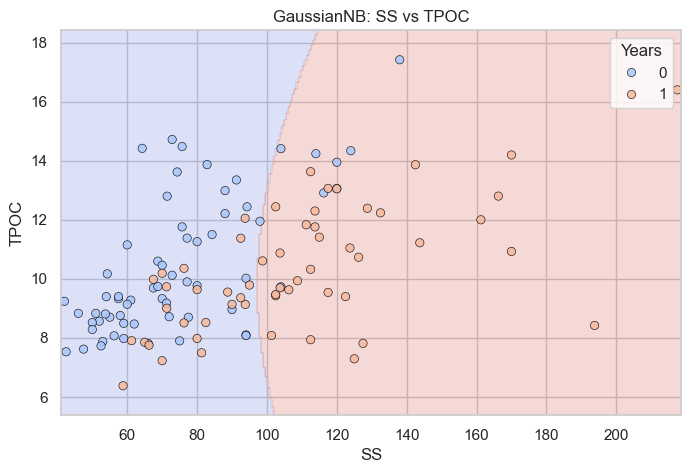

In [7]:
result_1 = run_gnb_for_pair(df, feature_pair=('SS', 'TPOC'))

## Powtorzenie procedury dla innej pary

=== Para cech: Depth i PSU ===
Accuracy: 0.6667

Confusion matrix:
[[18  1]
 [11  6]]

Classification report:
              precision    recall  f1-score   support

           0     0.6207    0.9474    0.7500        19
           1     0.8571    0.3529    0.5000        17

    accuracy                         0.6667        36
   macro avg     0.7389    0.6502    0.6250        36
weighted avg     0.7323    0.6667    0.6319        36


Przykladowe prawdopodobienstwa a posteriori (predict_proba):


,P(Years=0),P(Years=1),y_true,y_pred
0,0.566735,0.433265,0,0
1,0.636414,0.363586,0,0
2,0.688957,0.311043,0,0
3,0.717753,0.282247,0,0
4,0.539418,0.460582,0,0
5,0.074063,0.925937,1,1
6,0.420665,0.579335,1,1
7,0.510723,0.489277,0,0
8,0.183257,0.816743,1,1
9,0.617269,0.382731,0,0


C:\Users\mix13\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


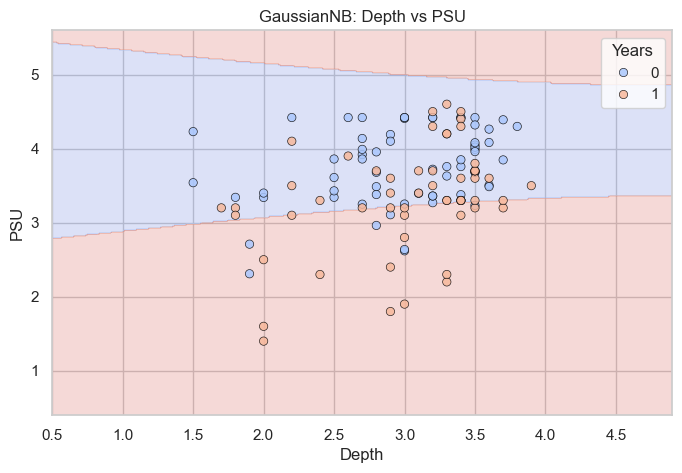

In [8]:
result_2 = run_gnb_for_pair(df, feature_pair=('Depth', 'PSU'))

In [9]:
comparison = pd.DataFrame([
    {'Para cech': ', '.join(result_1['features']), 'Accuracy': result_1['accuracy']},
    {'Para cech': ', '.join(result_2['features']), 'Accuracy': result_2['accuracy']}
]).sort_values('Accuracy', ascending=False)

display(comparison)

best_pair = comparison.iloc[0]
print(f"Najlepsza para cech w tym podziale: {best_pair['Para cech']} (accuracy={best_pair['Accuracy']:.4f})")

,Para cech,Accuracy
0,"SS, TPOC",0.777778
1,"Depth, PSU",0.666667


Najlepsza para cech w tym podziale: SS, TPOC (accuracy=0.7778)
